In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load dataset
df = pd.read_csv("Sugarcane_Irrigation_Dataset_5000.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (5000, 17)


,rainfall_mm,avg_temperature_celsius,sunlight_hours_per_day,nitrogen_n_kg_per_acre,phosphorus_p_kg_per_acre,potassium_k_kg_per_acre,soil_type,crop_duration_days,irrigation_frequency_per_month,pest_control_applied,seed_variety,yield_quintal_per_acre,soil_ph,relative_humidity_percent,wind_speed_kmph,soil_moisture_percent,water_requirement_liters_per_day
0,1734.13,33.61,8.95,214.67,76.90,94.82,Alluvial,400,3,1.00,Co86032,520.17,6.82,88.9,10.1,36.1,15.9
1,1286.61,31.25,7.89,163.85,61.71,80.61,Alluvial,374,3,0.95,CoM0265,463.89,6.99,82.2,8.1,28.1,18.2
2,1323.73,29.54,7.52,133.31,48.41,65.28,Red Soil,352,2,0.99,Co0238,343.14,6.50,77.9,8.6,35.0,18.5
3,1459.15,32.62,8.55,190.85,69.67,82.79,Clay Loam,384,4,1.00,Co0238,508.21,6.83,87.5,10.7,33.0,19.6
4,1114.87,30.31,7.92,148.93,57.00,71.42,Clay Loam,359,4,1.00,CoM0265,433.10,7.10,79.0,20.1,25.8,18.6


In [ ]:
selected_attributes = [
    "irrigation_frequency_per_month",
    "soil_moisture_percent"
]

print("Selected Attributes:")
for attribute in selected_attributes:
    print("-", attribute)

Selected Attributes:
- irrigation_frequency_per_month
- soil_moisture_percent


irrigation_frequency_per_month was selected because it represents the number of irrigation events occurring within a fixed monthly interval, making it suitable for investigating a Poisson distribution. soil_moisture_percent was selected as a continuous measurement that can be studied using a continuous probability distribution such as the Normal distribution.

In [ ]:
# Calculate mean, median and standard deviation

for column in selected_attributes:
    print("\nAttribute:", column)
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Standard Deviation:", df[column].std())


Attribute: soil_moisture_percent
Mean: 31.996940000000002
Median: 31.9
Standard Deviation: 5.9392056260996275

Attribute: yield_quintal_per_acre
Mean: 400.432326
Median: 408.4
Standard Deviation: 114.25265525341706


Mean and median describe the central tendency of each variable, while standard deviation indicates the amount of variation around the mean. These measures provide the basic statistical characteristics required for further distribution analysis.

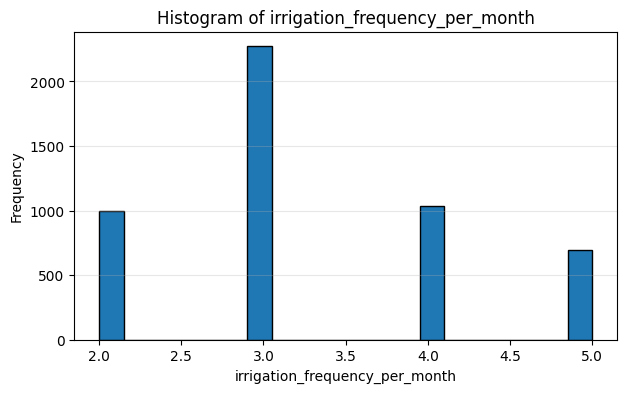

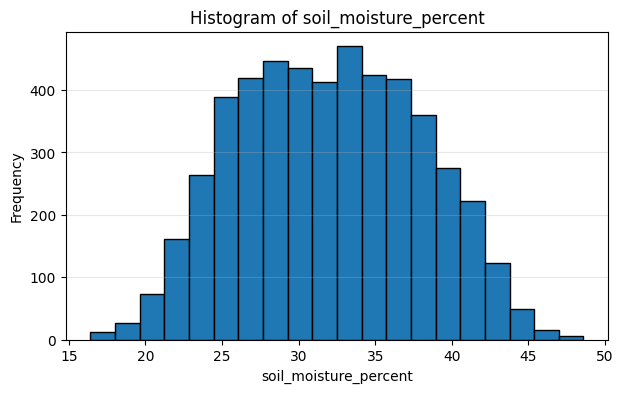

In [ ]:
# Plot histograms

for column in selected_attributes:
    plt.figure(figsize=(7, 4))

    plt.hist(
        df[column],
        bins=20,
        edgecolor="black"
    )

    plt.title("Histogram of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(axis="y", alpha=0.3)

    plt.show()

irrigation_frequency_per_month-
The histogram shows that irrigation frequency takes discrete values from 2 to 5 times per month, with the highest frequency at 3 irrigations per month. The distribution is not symmetric and shows a slight positive (right) skew, with frequencies decreasing toward higher irrigation frequencies.
soil_moisture_percent-
The histogram shows an approximately bell-shaped and symmetric distribution, with most soil-moisture values concentrated around 30–35%. The frequencies decrease gradually toward both lower and higher values, indicating that the distribution has low skewness and is approximately normally distributed.

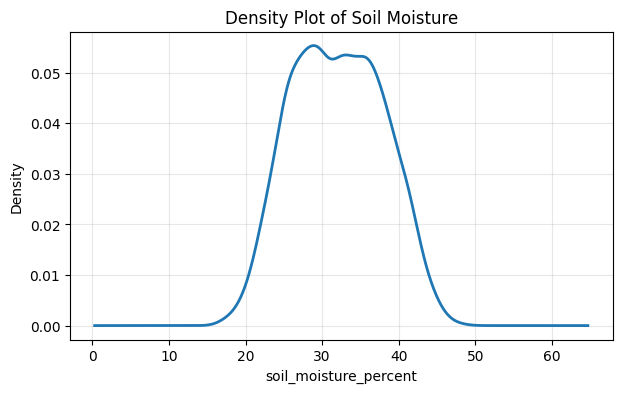

In [ ]:
# Density plot for continuous soil moisture

plt.figure(figsize=(7, 4))

df["soil_moisture_percent"].plot(
    kind="density",
    linewidth=2
)

plt.title("Density Plot of Soil Moisture")
plt.xlabel("soil_moisture_percent")
plt.ylabel("Density")
plt.grid(alpha=0.3)

plt.show()

The density plot shows that soil moisture is mainly concentrated between 25% and 40%, with the highest density around 30–35%. The curve is approximately bell-shaped and fairly balanced on both sides, indicating that the soil-moisture data is approximately symmetric with low skewness and reasonably close to a normal distribution.

In [ ]:
# Calculate skewness

for column in selected_attributes:

    skewness = df[column].skew()

    print("\nAttribute:", column)
    print("Skewness:", skewness)

    if abs(skewness) < 0.5:
        print("Interpretation: Approximately symmetric")
    elif skewness >= 0.5:
        print("Interpretation: Positively / right skewed")
    else:
        print("Interpretation: Negatively / left skewed")


Attribute: irrigation_frequency_per_month
Skewness: 0.4141623395213887
Interpretation: Approximately symmetric

Attribute: soil_moisture_percent
Skewness: 0.04877251603005591
Interpretation: Approximately symmetric


irrigation_frequency_per_month — Skewness = 0.414: The distribution is approximately symmetric, with a slight positive tendency, but the skewness is low.
soil_moisture_percent — Skewness = 0.049: The distribution is almost perfectly symmetric and very close to a normal distribution.

In [ ]:
# Identify potential outliers using IQR

for column in selected_attributes:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("\nAttribute:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Potential Outliers:", len(outliers))


Attribute: irrigation_frequency_per_month
Q1: 3.0
Q3: 4.0
IQR: 1.0
Lower Bound: 1.5
Upper Bound: 5.5
Number of Potential Outliers: 0

Attribute: soil_moisture_percent
Q1: 27.3
Q3: 36.6
IQR: 9.3
Lower Bound: 13.35
Upper Bound: 50.550000000000004
Number of Potential Outliers: 0


irrigation_frequency_per_month: Q1 = 3, Q3 = 4, and IQR = 1. The acceptable range is 1.5 to 5.5. Since there are 0 potential outliers, all observations fall within the expected range.
soil_moisture_percent: Q1 = 27.3%, Q3 = 36.6%, and IQR = 9.3. The acceptable range is 13.35% to 50.55%. Since there are 0 potential outliers, no potential outliers were detected.

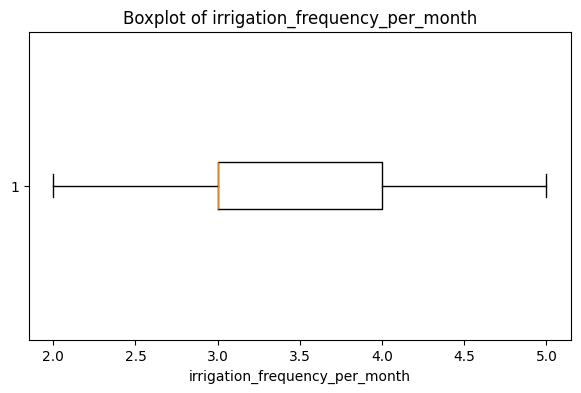

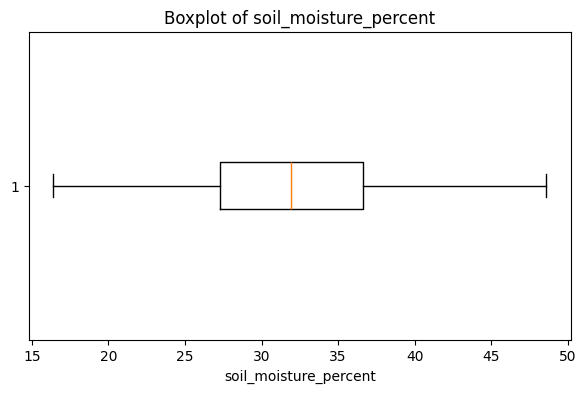

In [ ]:
# Boxplots

for column in selected_attributes:

    plt.figure(figsize=(7, 4))

    plt.boxplot(
        df[column],
        vert=False
    )

    plt.title("Boxplot of " + column)
    plt.xlabel(column)

    plt.show()

irrigation_frequency_per_month: The boxplot shows values ranging from 2 to 5 irrigations per month, with the median at approximately 3. There are no points outside the whiskers, confirming that no potential outliers were detected.
soil_moisture_percent: The boxplot shows a median of approximately 32%, with the middle 50% of observations lying between 27.3% and 36.6%. The whiskers extend approximately from 16% to 49%, with no potential outliers visible.

Mean (Lambda): 3.2856


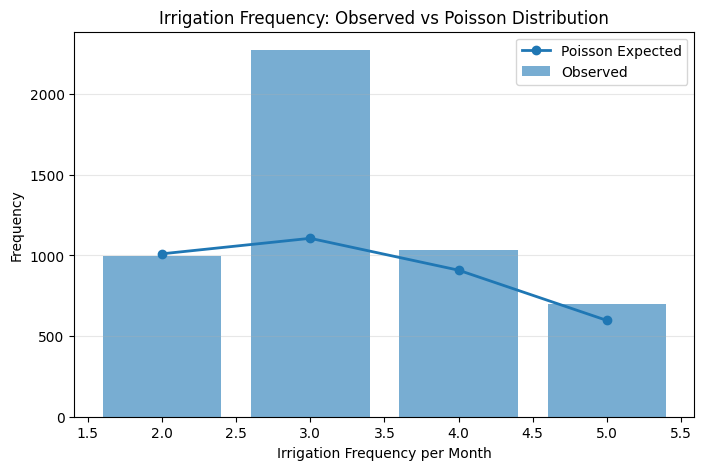

In [ ]:
# Poisson distribution comparison for irrigation frequency

data = df["irrigation_frequency_per_month"]

# Calculate lambda
lambda_value = data.mean()

print("Mean (Lambda):", lambda_value)

# Observed frequency
observed_counts = data.value_counts().sort_index()

# Poisson probabilities
x = np.arange(
    int(data.min()),
    int(data.max()) + 1
)

poisson_probabilities = stats.poisson.pmf(
    x,
    lambda_value
)

# Expected frequencies
expected_counts = (
    poisson_probabilities * len(data)
)

# Plot observed and expected frequencies
plt.figure(figsize=(8, 5))

plt.bar(
    observed_counts.index,
    observed_counts.values,
    alpha=0.6,
    label="Observed"
)

plt.plot(
    x,
    expected_counts,
    marker="o",
    linewidth=2,
    label="Poisson Expected"
)

plt.title("Irrigation Frequency: Observed vs Poisson Distribution")
plt.xlabel("Irrigation Frequency per Month")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

The observed irrigation-frequency data shows frequencies of approximately 1000, 2300, 1030, and 700 for 2, 3, 4, and 5 irrigations per month respectively. The Poisson distribution follows the same general pattern, with the highest expected frequency around 3 irrigations per month, but it does not match the observed frequencies closely, particularly at 3 irrigations. Therefore, the data shows some similarity to a Poisson distribution but does not closely follow the fitted Poisson model.

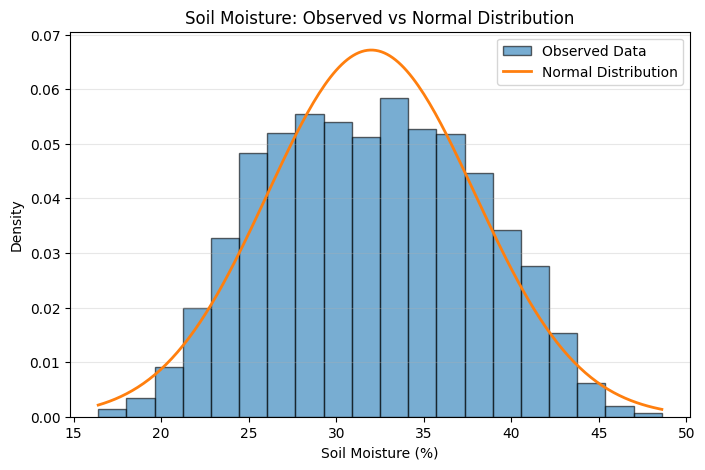

In [ ]:
# Normal distribution comparison for soil moisture

data = df["soil_moisture_percent"]

mean = data.mean()
std = data.std()

# Generate x values
x = np.linspace(
    data.min(),
    data.max(),
    200
)

# Normal probability density
normal_curve = stats.norm.pdf(
    x,
    mean,
    std
)

# Plot
plt.figure(figsize=(8, 5))

plt.hist(
    data,
    bins=20,
    density=True,
    alpha=0.6,
    edgecolor="black",
    label="Observed Data"
)

plt.plot(
    x,
    normal_curve,
    linewidth=2,
    label="Normal Distribution"
)

plt.title("Soil Moisture: Observed vs Normal Distribution")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Density")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

The observed soil-moisture distribution follows a roughly bell-shaped pattern and shows reasonable similarity to the fitted Normal distribution. Most observations are concentrated around 25–40%, with the highest density near 30–35%. The observed data does not perfectly match the Normal curve, but its approximately symmetric shape and low skewness (0.049) indicate that soil moisture is reasonably close to a normal distribution.

In [ ]:
# Statistical summary

summary = df[selected_attributes].agg(
    ["mean", "median", "std", "min", "max"]
)

# Add skewness
summary.loc["skewness"] = df[selected_attributes].skew()

display(summary)


,irrigation_frequency_per_month,soil_moisture_percent
mean,3.285600,31.996940
median,3.000000,31.900000
std,0.939260,5.939206
min,2.000000,16.400000
max,5.000000,48.600000
skewness,0.414162,0.048773


irrigation_frequency_per_month has a mean of 3.286 and median of 3, with a standard deviation of 0.939, indicating moderate variation in monthly irrigation frequency. Its skewness of 0.414 indicates an approximately symmetric distribution with a slight positive tendency. soil_moisture_percent has a mean of 31.997% and median of 31.9%, with a standard deviation of 5.939%. Its skewness of 0.049 indicates an almost perfectly symmetric distribution, which is consistent with its approximately normal-shaped histogram. Neither attribute shows extreme values based on the observed minimum and maximum ranges.

In [ ]:
for column in selected_attributes:

    skewness = df[column].skew()

    print("=" * 60)
    print("Attribute:", column)
    print("Mean:", round(df[column].mean(), 3))
    print("Median:", round(df[column].median(), 3))
    print("Standard Deviation:", round(df[column].std(), 3))
    print("Skewness:", round(skewness, 3))

    if abs(skewness) < 0.5:
        print("Distribution: Approximately symmetric")
    elif skewness >= 0.5:
        print("Distribution: Positively/right skewed")
    else:
        print("Distribution: Negatively/left skewed")

Attribute: irrigation_frequency_per_month
Mean: 3.286
Median: 3.0
Standard Deviation: 0.939
Skewness: 0.414
Distribution: Approximately symmetric
Attribute: soil_moisture_percent
Mean: 31.997
Median: 31.9
Standard Deviation: 5.939
Skewness: 0.049
Distribution: Approximately symmetric


The results show that both selected variables have approximately symmetric distributions. irrigation_frequency_per_month has a mean of 3.286, median of 3.0, standard deviation of 0.939, and skewness of 0.414. soil_moisture_percent has a mean of 31.997%, median of 31.9%, standard deviation of 5.939%, and skewness of 0.049. Thus, soil moisture is very close to symmetric, while irrigation frequency shows a slight positive tendency.

**CONCLUSION**

The probability distributions of irrigation_frequency_per_month and soil_moisture_percent were successfully analyzed using statistical and graphical techniques. Mean, median, standard deviation, and skewness were calculated, while histograms and density plots were used to study their distributions. Potential outliers were identified using the IQR method, with no potential outliers detected in either attribute. The irrigation-frequency data was compared with a Poisson distribution, while soil moisture was compared with a Normal distribution. Overall, the analysis provided an understanding of the distribution, variability, skewness, and statistical characteristics of the selected variables, supporting further analysis of the sugarcane irrigation dataset.